# Machine Learning Classifier for Lung Disease

## Convolutional Neural Network

A convolutional neural network is a special type of neural network designed for identifying patterns in images by learning the filters found in images. 

In [3]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.utils import class_weight

import matplotlib.pyplot as plt
from tqdm import tqdm

### Load Data set

The following code is to load the images into an array that can be passed through the tensorflow CNN architecture.

In [4]:
def load_lung_disease_dataset_cnn(base_path, img_size=(224, 224), clahe_on=True):
    data = []
    labels = []
    
    if not os.path.exists(base_path):
        print(f"Error: Path {base_path} not found.")
        return None, None
        
    class_names = sorted([f for f in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, f))])
    
    if clahe_on:
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    
    for idx, label in enumerate(class_names):
        folder_path = os.path.join(base_path, label)
        files = os.listdir(folder_path)
        
        for img_name in tqdm(files, desc=f"Loading {label}", leave=False):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
            if img is None:
                continue
            
            if clahe_on:
                img = clahe.apply(img)
                
            img = cv2.resize(img, img_size)
            
            data.append(img / 255.0)
            labels.append(idx)
            
    return np.array(data, dtype=np.float32), np.array(labels, dtype=np.int32)

As discussed in the Logistic Regression part, CLAHE can be significant in identifying patterns in medical images. For the initial CNN model we will see how it will perform without it.

In [4]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined', clahe_on=False)

### Split Dataset
The data set is split three-Way (Train 70%, Val 15%, Test 15%) while ensuring that the split is stratified to avoid underrepresentation.

In [5]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

This plot will show 25 examples taken from the dataset

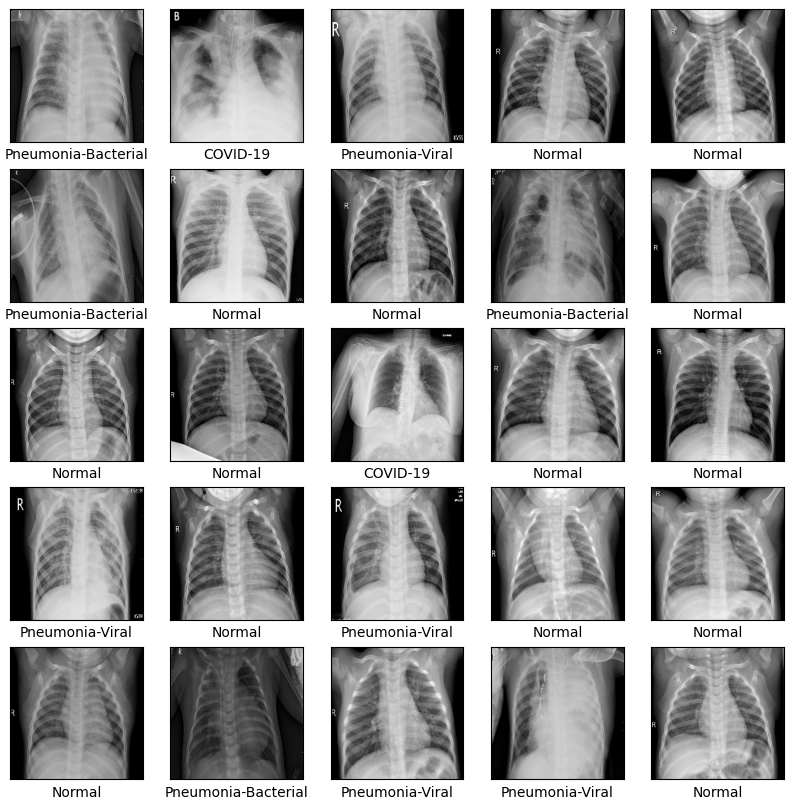

In [7]:
classes = ["COVID-19", "Normal", "Pneumonia-Bacterial", "Pneumonia-Viral"]

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap='gray')
    plt.xlabel(classes[y_train[i]])
plt.show()

## Model construction
Below is a shallow CNN model with 3 convolutional layers and a maps them to 4 output classes through a dense bottleneck. The code below and the training code is taken and modified from the CNN Tensorflow for the CIFAR digits dataset. This already utilizes techniques discussed in the class namely the ADAM optimizer to leverage both momentum and RMSProp.

In [ ]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(4))
model.summary()

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))

Below will show the performance of the CNN Model without CLAHE.


Evaluating model on unseen Test Set...
44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 281ms/step
              precision    recall  f1-score   support

           0       0.96      0.89      0.92       192
           1       0.93      0.97      0.95       491
           2       0.82      0.70      0.76       450
           3       0.57      0.70      0.63       249

    accuracy                           0.82      1382
   macro avg       0.82      0.82      0.81      1382
weighted avg       0.83      0.82      0.83      1382



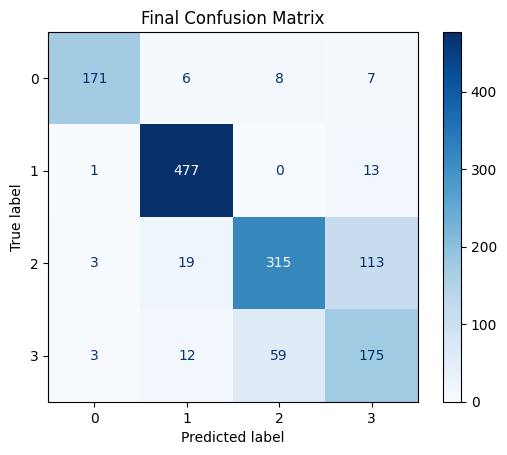

In [10]:
print("\nEvaluating model on unseen Test Set...")
all_preds = model.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

## Model Performance
As seen with the results, the model had a training accuracy of around 95% whereas the test accuracy is 82% which is a good starting point. The Confusion matrix shows that the issue largely lies the same as with the Logistic Regression model, where the model confuses the two kinds of pneumonia.

## With CLAHE
We will reload the dataset now with CLAHE activated, and go through the train, test and validation split once again.

In [6]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined')

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=42, stratify=y_train_full
)

X_train = X_train.reshape(-1, 224, 224, 1)
X_val = X_val.reshape(-1, 224, 224, 1)
X_test = X_test.reshape(-1, 224, 224, 1)

In [ ]:
model_clahe = models.Sequential()
model_clahe.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model_clahe.add(layers.MaxPooling2D((2, 2)))
model_clahe.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_clahe.add(layers.MaxPooling2D((2, 2)))
model_clahe.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_clahe.add(layers.Flatten())
model_clahe.add(layers.Dense(64, activation='relu'))
model_clahe.add(layers.Dense(4))

model_clahe.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model_clahe.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))


Evaluating model on unseen Test Set...
44/44 ━━━━━━━━━━━━━━━━━━━━ 17s 380ms/step
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       192
           1       0.91      0.99      0.95       491
           2       0.81      0.86      0.84       450
           3       0.75      0.55      0.63       249

    accuracy                           0.86      1382
   macro avg       0.86      0.84      0.84      1382
weighted avg       0.86      0.86      0.85      1382



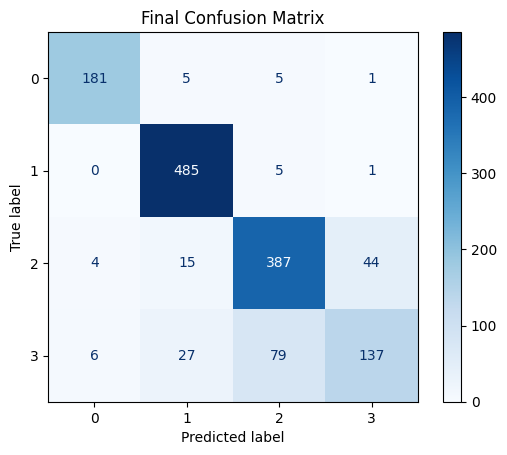

In [13]:
print("\nEvaluating model on unseen Test Set...")
all_preds = model_clahe.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

## Model Performance
The performance of this model slightly outperforms the one without CLAHE with 99% and 86% accuracies for the training and test data respectively. This shows that applying CLAHE has a slightly positive effect on the performance of a model if we look at the values of their accuracies. The model still suffers the same problem as the other models that come before it, confusing the two kinds of pneumonia. 

## Batch normalization and dropout
While 86% is a strong value, the common goal is to have it at at least 90%, and as we see, the issue of the confusion between the two pnuemonia classes remains. For the following model, batch normalization and dropout will be tested to see if it can improve the model.

In [ ]:

model_bn_d = models.Sequential()

model_bn_d.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(224, 224, 1)))
model_bn_d.add(layers.BatchNormalization())
model_bn_d.add(layers.Activation('relu'))
model_bn_d.add(layers.MaxPooling2D((2, 2)))
model_bn_d.add(layers.Dropout(0.2)) 

model_bn_d.add(layers.Conv2D(64, (3, 3), padding='same'))
model_bn_d.add(layers.BatchNormalization())
model_bn_d.add(layers.Activation('relu'))
model_bn_d.add(layers.MaxPooling2D((2, 2)))
model_bn_d.add(layers.Dropout(0.3))

model_bn_d.add(layers.Conv2D(128, (3, 3), padding='same')) 
model_bn_d.add(layers.BatchNormalization())
model_bn_d.add(layers.Activation('relu'))
model_bn_d.add(layers.MaxPooling2D((2, 2)))
model_bn_d.add(layers.Dropout(0.4))

model_bn_d.add(layers.Flatten())
model_bn_d.add(layers.Dense(128)) 
model_bn_d.add(layers.BatchNormalization())
model_bn_d.add(layers.Activation('relu'))
model_bn_d.add(layers.Dropout(0.5))

model_bn_d.add(layers.Dense(4, activation='softmax')) 
model_bn_d.summary()

In [ ]:
model_bn_d.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model_bn_d.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_val, y_val))


Evaluating model on unseen Test Set...
44/44 ━━━━━━━━━━━━━━━━━━━━ 28s 552ms/step
              precision    recall  f1-score   support

           0       0.99      0.94      0.97       192
           1       0.95      0.99      0.97       491
           2       0.83      0.84      0.83       450
           3       0.70      0.67      0.69       249

    accuracy                           0.87      1382
   macro avg       0.87      0.86      0.86      1382
weighted avg       0.87      0.87      0.87      1382



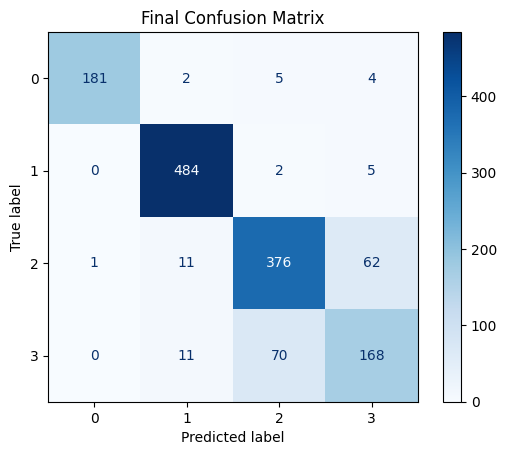

In [16]:
print("\nEvaluating model on unseen Test Set...")
all_preds = model_bn_d.predict(X_test)

predicted_classes = np.argmax(all_preds, axis=1)

print(classification_report(y_test, predicted_classes))

y_test_flat = y_test.flatten().astype(np.int32)

cm = confusion_matrix(y_test_flat, predicted_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Final Confusion Matrix")
plt.show()

## Model Performance
It can be seen that Batch Normalization and Dropout increased the accuracy of the model by 1% while taking more than twice as long to train. The pattern is evident once more that the model struggles to differentiate between bacterial and viral pneumonia.

## Multistage CNN
Since the models were seen struggling with just two identical classes, we decided that it might be better to handle that as a seperate sub-problem and then categorize both classes as simply a "Pnuemonia" class initially, before identifying whether it is bacterial or viral. To accomplish this approach, we employed a two stage CNN where the first stage would categorize the image to either COVID-19, Normal or Pnuemonia, while if it was classified as Pnuemonia, it will pass through stage 2 to classify it under bacterial or viral pnuemonia.

In [5]:
X, y = load_lung_disease_dataset_cnn('1/dataset_combined')

ORIG_COVID      = 0
ORIG_NORMAL     = 1
ORIG_PNEUMO_BAC = 2
ORIG_PNEUMO_VIR = 3

S1_COVID    = 0
S1_NORMAL   = 1
S1_PNEUMO   = 2

S2_BACTERIAL = 0
S2_VIRAL     = 1

Below we split the data to get the Pnuemonia afflicted lung images and create seperate arrays so that the stage 2 model will only deal with either the two classes of Pnuemonia.

In [6]:
#  Remap labels for Stage 1 
y_s1 = np.where(y == ORIG_PNEUMO_BAC, S1_PNEUMO,
       np.where(y == ORIG_PNEUMO_VIR, S1_PNEUMO, y)).astype(np.int32)

# Build Stage 2 subset (pneumonia samples only) 
pneumo_mask = (y == ORIG_PNEUMO_BAC) | (y == ORIG_PNEUMO_VIR)
X_pneumo    = X[pneumo_mask]
y_s2        = np.where(y[pneumo_mask] == ORIG_PNEUMO_BAC, S2_BACTERIAL, S2_VIRAL).astype(np.int32)

# Train / val / test splits 
# Stage 1 splits (full dataset)
X_train_full, X_test,  y_s1_train_full, y_s1_test = train_test_split(
    X, y_s1, test_size=0.15, random_state=42, stratify=y_s1
)
X_train, X_val, y_s1_train, y_s1_val = train_test_split(
    X_train_full, y_s1_train_full, test_size=0.176, random_state=42, stratify=y_s1_train_full
)

# Stage 2 splits (pneumonia subset)
X_p_train_full, X_p_test, y_s2_train_full, y_s2_test = train_test_split(
    X_pneumo, y_s2, test_size=0.15, random_state=42, stratify=y_s2
)
X_p_train, X_p_val, y_s2_train, y_s2_val = train_test_split(
    X_p_train_full, y_s2_train_full, test_size=0.176, random_state=42, stratify=y_s2_train_full
)

X_train   = X_train.reshape(-1, 224, 224, 1)
X_val     = X_val.reshape(-1, 224, 224, 1)
X_test    = X_test.reshape(-1, 224, 224, 1)
X_p_train = X_p_train.reshape(-1, 224, 224, 1)
X_p_val   = X_p_val.reshape(-1, 224, 224, 1)
X_p_test  = X_p_test.reshape(-1, 224, 224, 1)

In [7]:
indices = np.arange(len(X))

idx_train_full, idx_test, y_s1_train_full, y_s1_test = train_test_split(
    indices, y_s1, test_size=0.15, random_state=42, stratify=y_s1
)
idx_train, idx_val, y_s1_train, y_s1_val = train_test_split(
    idx_train_full, y_s1_train_full, test_size=0.176, random_state=42, stratify=y_s1_train_full
)

X_train = X[idx_train]
X_val   = X[idx_val]
X_test  = X[idx_test]
y_test_orig = y[idx_test]

In [6]:
# Helper: build the shared CNN architecture 
def build_cnn(num_classes, name):
    m = models.Sequential(name=name)
    m.add(layers.Conv2D(32, (3, 3), padding='same', input_shape=(224, 224, 1)))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(0.2))

    m.add(layers.Conv2D(64, (3, 3), padding='same'))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(0.3))

    m.add(layers.Conv2D(128, (3, 3), padding='same'))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.MaxPooling2D((2, 2)))
    m.add(layers.Dropout(0.4))

    m.add(layers.Flatten())
    m.add(layers.Dense(128))
    m.add(layers.BatchNormalization())
    m.add(layers.Activation('relu'))
    m.add(layers.Dropout(0.5))

    m.add(layers.Dense(num_classes, activation='softmax'))
    return m

In [ ]:
# Stage 1: COVID / Normal / Pneumonia (3 classes) 
stage1 = build_cnn(num_classes=3, name='stage1_coarse')
stage1.summary()
stage1.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

history_s1 = stage1.fit(X_train, y_s1_train, epochs=10,
                         validation_data=(X_val, y_s1_val))

In [ ]:
# Stage 2: Bacterial / Viral pneumonia (2 classes)
stage2 = build_cnn(num_classes=2, name='stage2_pneumonia')
stage2.summary()
stage2.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

history_s2 = stage2.fit(X_p_train, y_s2_train, epochs=10,
                          validation_data=(X_p_val, y_s2_val))

In [8]:
stage1 = tf.keras.models.load_model('lung_disease_model_cnn_s1.keras')
stage2 = tf.keras.models.load_model('lung_disease_model_cnn_s2.keras')

In [9]:
s1_probs = stage1.predict(X_test)
s1_preds = np.argmax(s1_probs, axis=1)          

final_preds = np.empty(len(X_test), dtype=np.int32)
pneumo_idx  = np.where(s1_preds == S1_PNEUMO)[0]

for i, idx in enumerate(pneumo_idx):
    img = X_test[idx:idx+1]                      
    s2_prob = stage2.predict(img, verbose=0)
    s2_pred = np.argmax(s2_prob)
    final_preds[idx] = ORIG_PNEUMO_BAC if s2_pred == S2_BACTERIAL else ORIG_PNEUMO_VIR

for idx in range(len(X_test)):
    if s1_preds[idx] == S1_COVID:
        final_preds[idx] = ORIG_COVID
    elif s1_preds[idx] == S1_NORMAL:
        final_preds[idx] = ORIG_NORMAL

44/44 ━━━━━━━━━━━━━━━━━━━━ 30s 662ms/step



Evaluating multistage model on unseen Test Set...
                     precision    recall  f1-score   support

            covid19       0.64      0.97      0.77       192
             normal       0.98      0.75      0.85       491
pneumonia_bacterial       0.92      0.84      0.88       455
    pneumonia_viral       0.71      0.88      0.79       244

           accuracy                           0.83      1382
          macro avg       0.81      0.86      0.82      1382
       weighted avg       0.87      0.83      0.84      1382



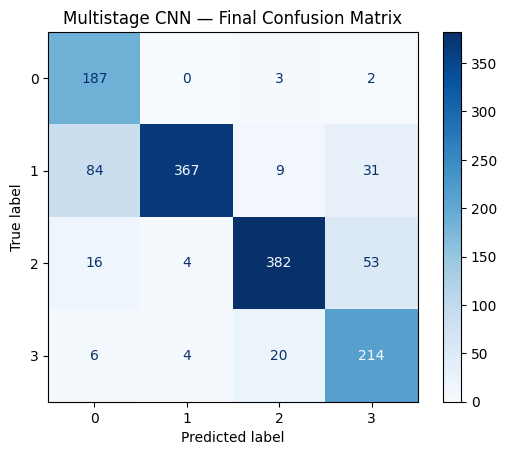

In [10]:
print("\nEvaluating multistage model on unseen Test Set...")
class_names_orig = ['covid19', 'normal', 'pneumonia_bacterial', 'pneumonia_viral']

print(classification_report(y_test_orig, final_preds, target_names=class_names_orig))

cm = confusion_matrix(y_test_orig, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Multistage CNN — Final Confusion Matrix")
plt.show()

In [ ]:
# Saving the multi-stage models since it took up too much RAM
stage1.save('lung_disease_model_cnn_s1.keras')
stage2.save('lung_disease_model_cnn_s2.keras')

## Model Performance

Interestingly, the initial stage model seemed to have trouble with identifying some lung images as Normal, as seen with the confusion matrix. Although this is the case, it did accomplish the initial goal of better identifying between the two pnuemonia classes compared to previous models.

## Model Evaluation
Having seen all the models perform, empirically, the single-stage CNN model that employed batch normalization and dropout had the best performance in terms of accuracy, however the issue with both pnuemonia classes was unresolved with that model. The single-stage got 181/192 (94% recall) for COVID while multistage got 187/192 (97% recall) whereas single-stage was near-perfect recall with normal (484/491, 98.6%), while multistage dropped to 367/491 (74.7% recall). One reason we may interpret with this is when we collapse the pnuemonia classes into one, the class distribution skewed even more heavily towards pnuemonia that may have blurred the boundary between COVID-19 and Noraml. A point of improvement might be to combine the last two models using the former as stage 1 and the later as stage 2.